# 1. pytorch 2.x으로 설치하기


실습하기에 앞서 파이토치 2.x으로 설치 필요!   
Colab에서는 바로 사용할 수 있다.

https://pytorch.org/examples/

In [1]:
import torch

torch.__version__

'2.11.0+cu128'

파이토치는 cpu, gpu 모두 사용할 수 있으며,  
colab의 경우 기본적으로 gpu가 설치된 버전으로 사용이 가능  
torch 버전을 출력해보면 나오는 버전+환경을 통해 확인이 가능하다.

In [2]:
# pytorch에서 사용할 함수들 호출하기
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR

먼저, datasets안에 들어있는 몇 가지 예제 데이터들 중에,  
mnist 데이터를 사용해보겠습니다.

In [3]:
train_dataset = datasets.MNIST('./data', train=True, download=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.97MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.55MB/s]


pytorch 데이터셋의 경우 PIL.Image와 라벨로 이루어져 있다

In [4]:
len(train_dataset)

60000

In [5]:
train_dataset[0]

(<PIL.Image.Image image mode=L size=28x28>, 5)

In [6]:
train_dataset[0][0]

In [7]:
import numpy as np
unique_class = np.unique([label for img, label in train_dataset])
print(unique_class)
len(unique_class)

[0 1 2 3 4 5 6 7 8 9]


10

지금은 이미지로 보이지만, 컴퓨터를 학습시키기 위해선 숫자로 바꿔주는 과정이 필요하다.

In [8]:
transform = transforms.Compose([
        transforms.ToTensor(), # 이미지를 tensor 자료형으로 변경
        transforms.Normalize((0.1307,), (0.3081,)) # 정규화
        ])

train_dataset.transform = transform

기본적으로 이미지를 tensor 자료형으로 변경할 경우  
한 이미지는 이미지 채널 수 (Gray or RGB), width, height 순의 배열로 나타난다.

In [9]:
train_dataset[0][0].shape

torch.Size([1, 28, 28])

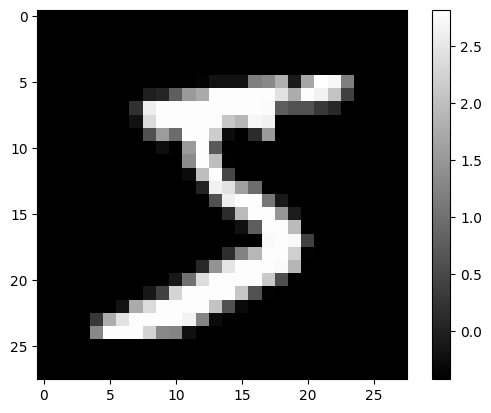

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(train_dataset[0][0].reshape(28, 28, 1), cmap='gray') # width, height, color channels
plt.colorbar()
plt.show()

pytorch의 데이터를 학습시키기 위해선 DataLoader로 바꿔주는 과정이 필요하다.  
참고로 dataset의 경우 데이터, 라벨로 이루어져 있어야 하고 iterable해야한다.

In [11]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

# 숫자 이미지 예측하기

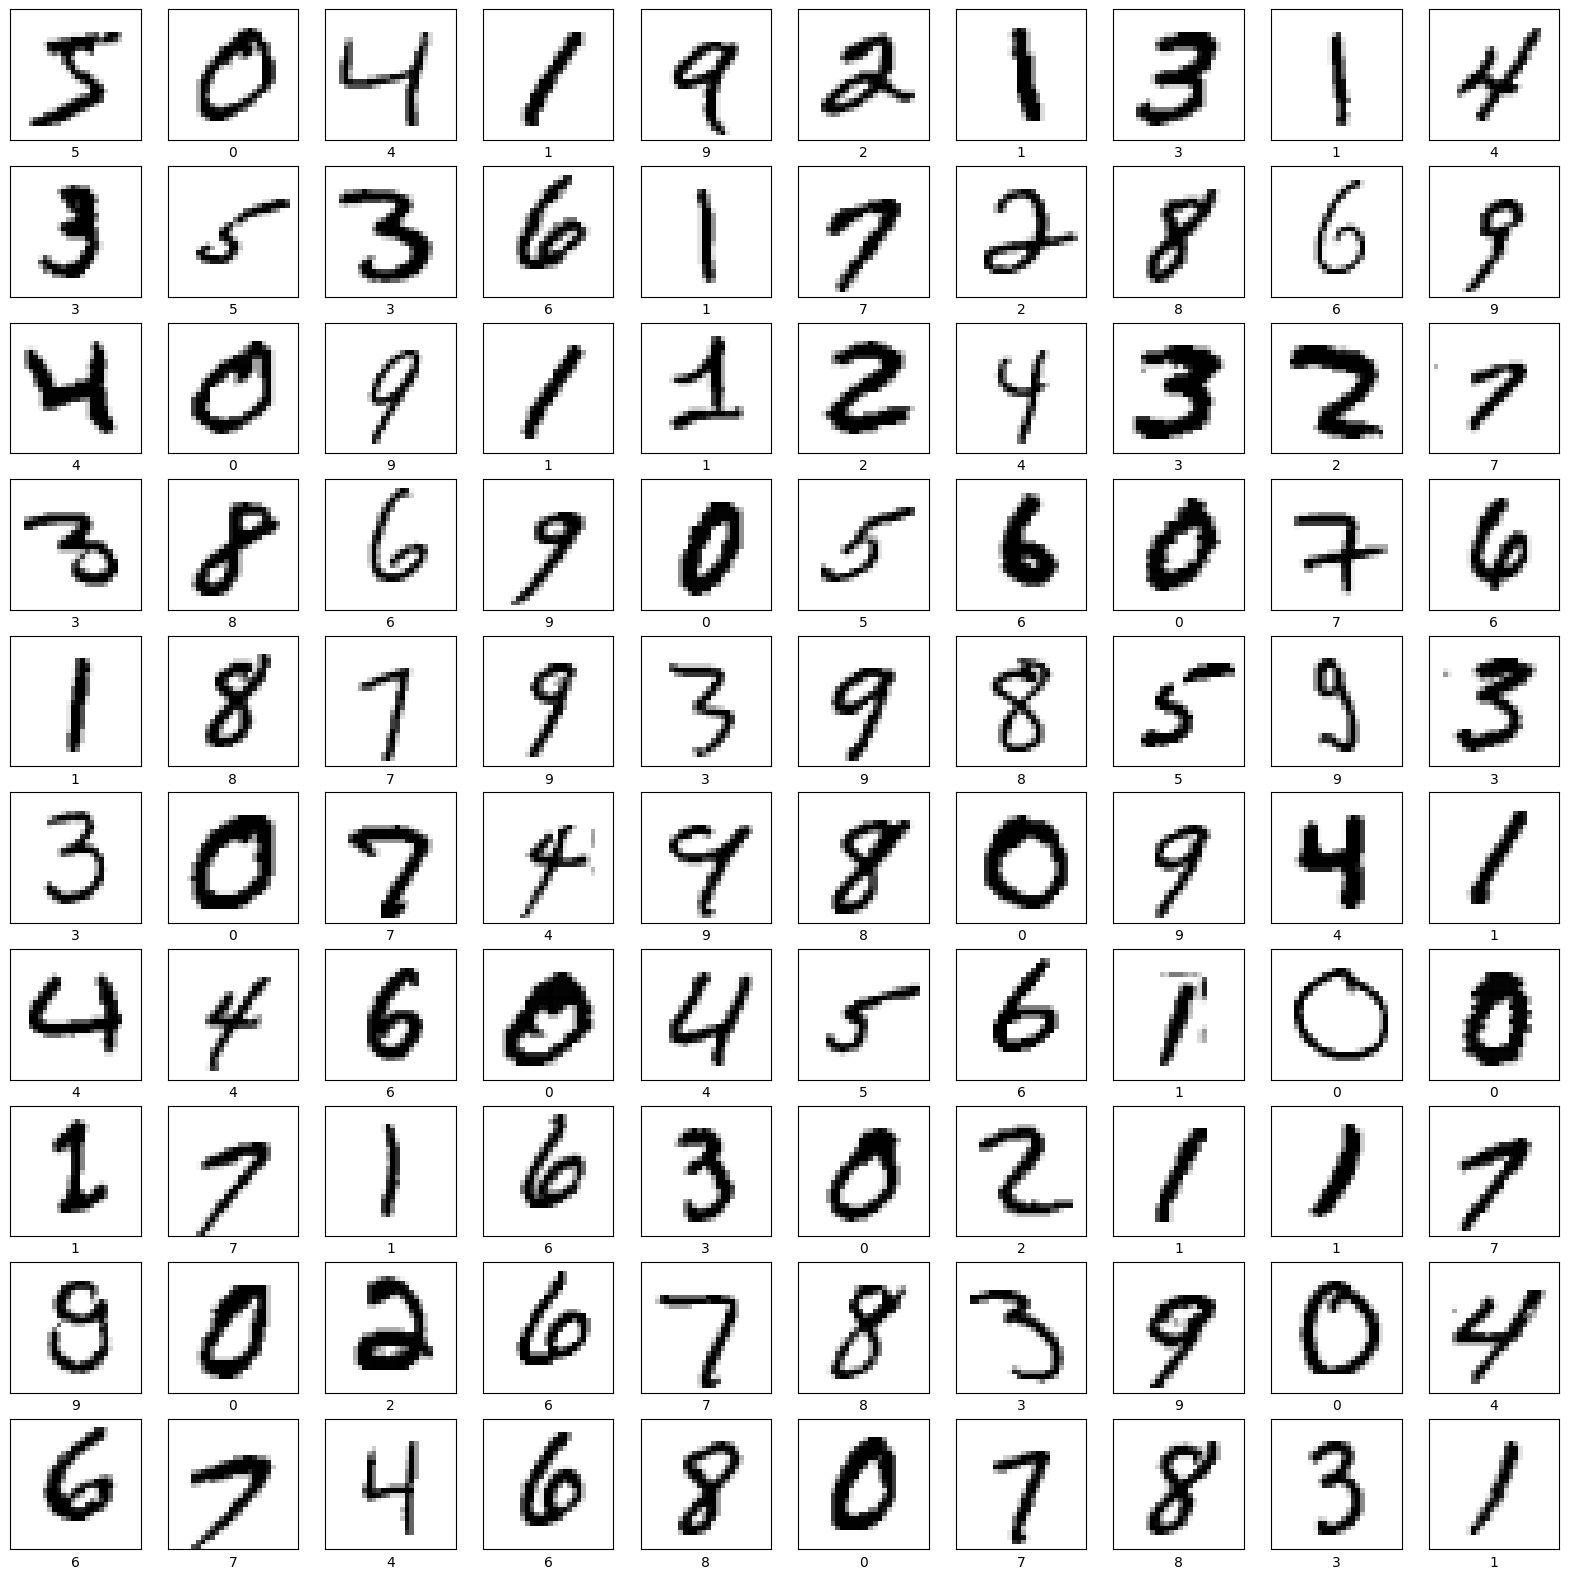

In [12]:
plt.figure(figsize=(20,20))
for i in range(100):
    plt.subplot(10,10,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_dataset[i][0].reshape(28, 28, 1), cmap=plt.cm.binary)
    plt.xlabel(train_dataset[i][1])
plt.show()

테스트 데이터 정의

In [13]:
# torchivision datasets
test_dataset = datasets.MNIST('./data', train=False, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32)

### 모델 구축

In [14]:
# 기본 모델 = 완전연결계층 = Linear
# Fully Connected Layer
class MyFirstModel(nn.Module):
    def __init__(self):
        super(MyFirstModel, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
            nn.Softmax()
        )

    def forward(self, x):
        output = self.model(x)
        return output

In [15]:
model = MyFirstModel()

### 모델 컴파일
모델을 훈련하기 전에 필요한 몇 가지 설정이 필요합니다.:

모델을 device로 이동 - 훈련 시 모델을 cpu, gpu로 이동시킵니다.  
옵티마이저(Optimizer)-데이터와 손실 함수를 바탕으로 모델의 업데이트 방법을 결정합니다.  
스케줄러(Scheduler)-학습률을 학습이 진행됨에 따라 적절한 값으로 변경하기 위해 사용합니다.


In [16]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

optimizer = optim.Adadelta(model.parameters(), lr=1.0)
scheduler = StepLR(optimizer, step_size=1, gamma=0.7)
# loss(criterion) = CrossEntropyLoss()

### 모델 훈련
신경망 모델을 훈련하는 단계는 다음과 같습니다:  
.  
model을 학습 상태로 변경합니다. (가중치 업데이트 가능한 상태)  
dataloader에서 뽑은 배치 사이즈만큼의 훈련 데이터를 device로 이동시킵니다.  

훈련 데이터를 모델에 주입합니다-이 예에서는 train_images와 train_labels 배열입니다.  
모델이 이미지와 레이블을 매핑하는 방법을 배웁니다.  

테스트 세트에 대한 모델의 예측을 만듭니다-이 예에서는 test_images 배열입니다.  
이 예측이 test_labels 배열의 레이블과 맞는지 확인합니다.  

Epoch : dataset 반복 횟수  
예를 들어,  
책 몇번 봤어? == 책 몇 epoch 돌렸어?  


손실 함수(Loss function)-훈련 하는 동안 모델의 오차를 측정합니다.  
모델의 학습이 올바른 방향으로 향하도록 이 함수를 최소화해야 합니다.  

In [17]:
epochs = 10
dry_run = False # 1 배치만 훈련

for epoch in range(1, epochs+1):
    # 학습
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad() # 기울기 초기화 -> 0으로
        output = model(data) # 모델에 데이터 주입 -> 예측값 뽑기 (함수 호출하듯이 작성하면 forward가 실행됨)
        loss = F.nll_loss(output, target) # 에러 계산
        loss.backward() # 오차 역전파 (기울기 계산 부분)
        optimizer.step() # 가중치 업데이트

        if batch_idx % 100 == 0: # 로깅
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
            if dry_run:
                break

    # 테스트
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad(): # 기울기 계산 X
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

    scheduler.step()

/usr/local/lib/python3.13/dist-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Train Epoch: 1 [0/60000 (0%)]	Loss: -0.100321
Train Epoch: 1 [3200/60000 (5%)]	Loss: -0.255630
Train Epoch: 1 [6400/60000 (11%)]	Loss: -0.416766
Train Epoch: 1 [9600/60000 (16%)]	Loss: -0.527237
Train Epoch: 1 [12800/60000 (21%)]	Loss: -0.552317
Train Epoch: 1 [16000/60000 (27%)]	Loss: -0.687540
Train Epoch: 1 [19200/60000 (32%)]	Loss: -0.718241
Train Epoch: 1 [22400/60000 (37%)]	Loss: -0.616432
Train Epoch: 1 [25600/60000 (43%)]	Loss: -0.687883
Train Epoch: 1 [28800/60000 (48%)]	Loss: -0.905098
Train Epoch: 1 [32000/60000 (53%)]	Loss: -0.749807
Train Epoch: 1 [35200/60000 (59%)]	Loss: -0.687266
Train Epoch: 1 [38400/60000 (64%)]	Loss: -0.771950
Train Epoch: 1 [41600/60000 (69%)]	Loss: -0.803637
Train Epoch: 1 [44800/60000 (75%)]	Loss: -0.804811
Train Epoch: 1 [48000/60000 (80%)]	Loss: -0.874999
Train Epoch: 1 [51200/60000 (85%)]	Loss: -0.843749
Train Epoch: 1 [54400/60000 (91%)]	Loss: -0.750000
Train Epoch: 1 [57600/60000 (96%)]	Loss: -0.931606

Test set: Average loss: -0.8040, Accura

KeyboardInterrupt: 

# 의류 이미지 예측하기

In [18]:
train_dataset = datasets.FashionMNIST('./fashion_data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST('./fashion_data', train=False, transform=transform)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 167kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.17MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.8MB/s]


**< dataset summary >**  
n_trainset = 60,000 / n_testset = 10,000  
1 image shape = 28 x 28 / 1 label shape = 1

In [19]:
unique_class = np.unique([label for img, label in train_dataset])
print(unique_class)
len(unique_class)

[0 1 2 3 4 5 6 7 8 9]


10

데이터셋 안에 label의 이름이 없기 때문에, 직접 넣어줍니다.

In [20]:
label_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

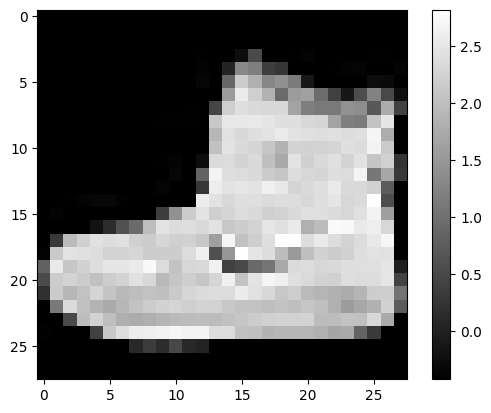

In [22]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(train_dataset[0][0].reshape(28, 28, 1), cmap='gray')
plt.colorbar()
plt.show()

In [23]:
label_names[train_dataset[0][1]]

'Ankle boot'

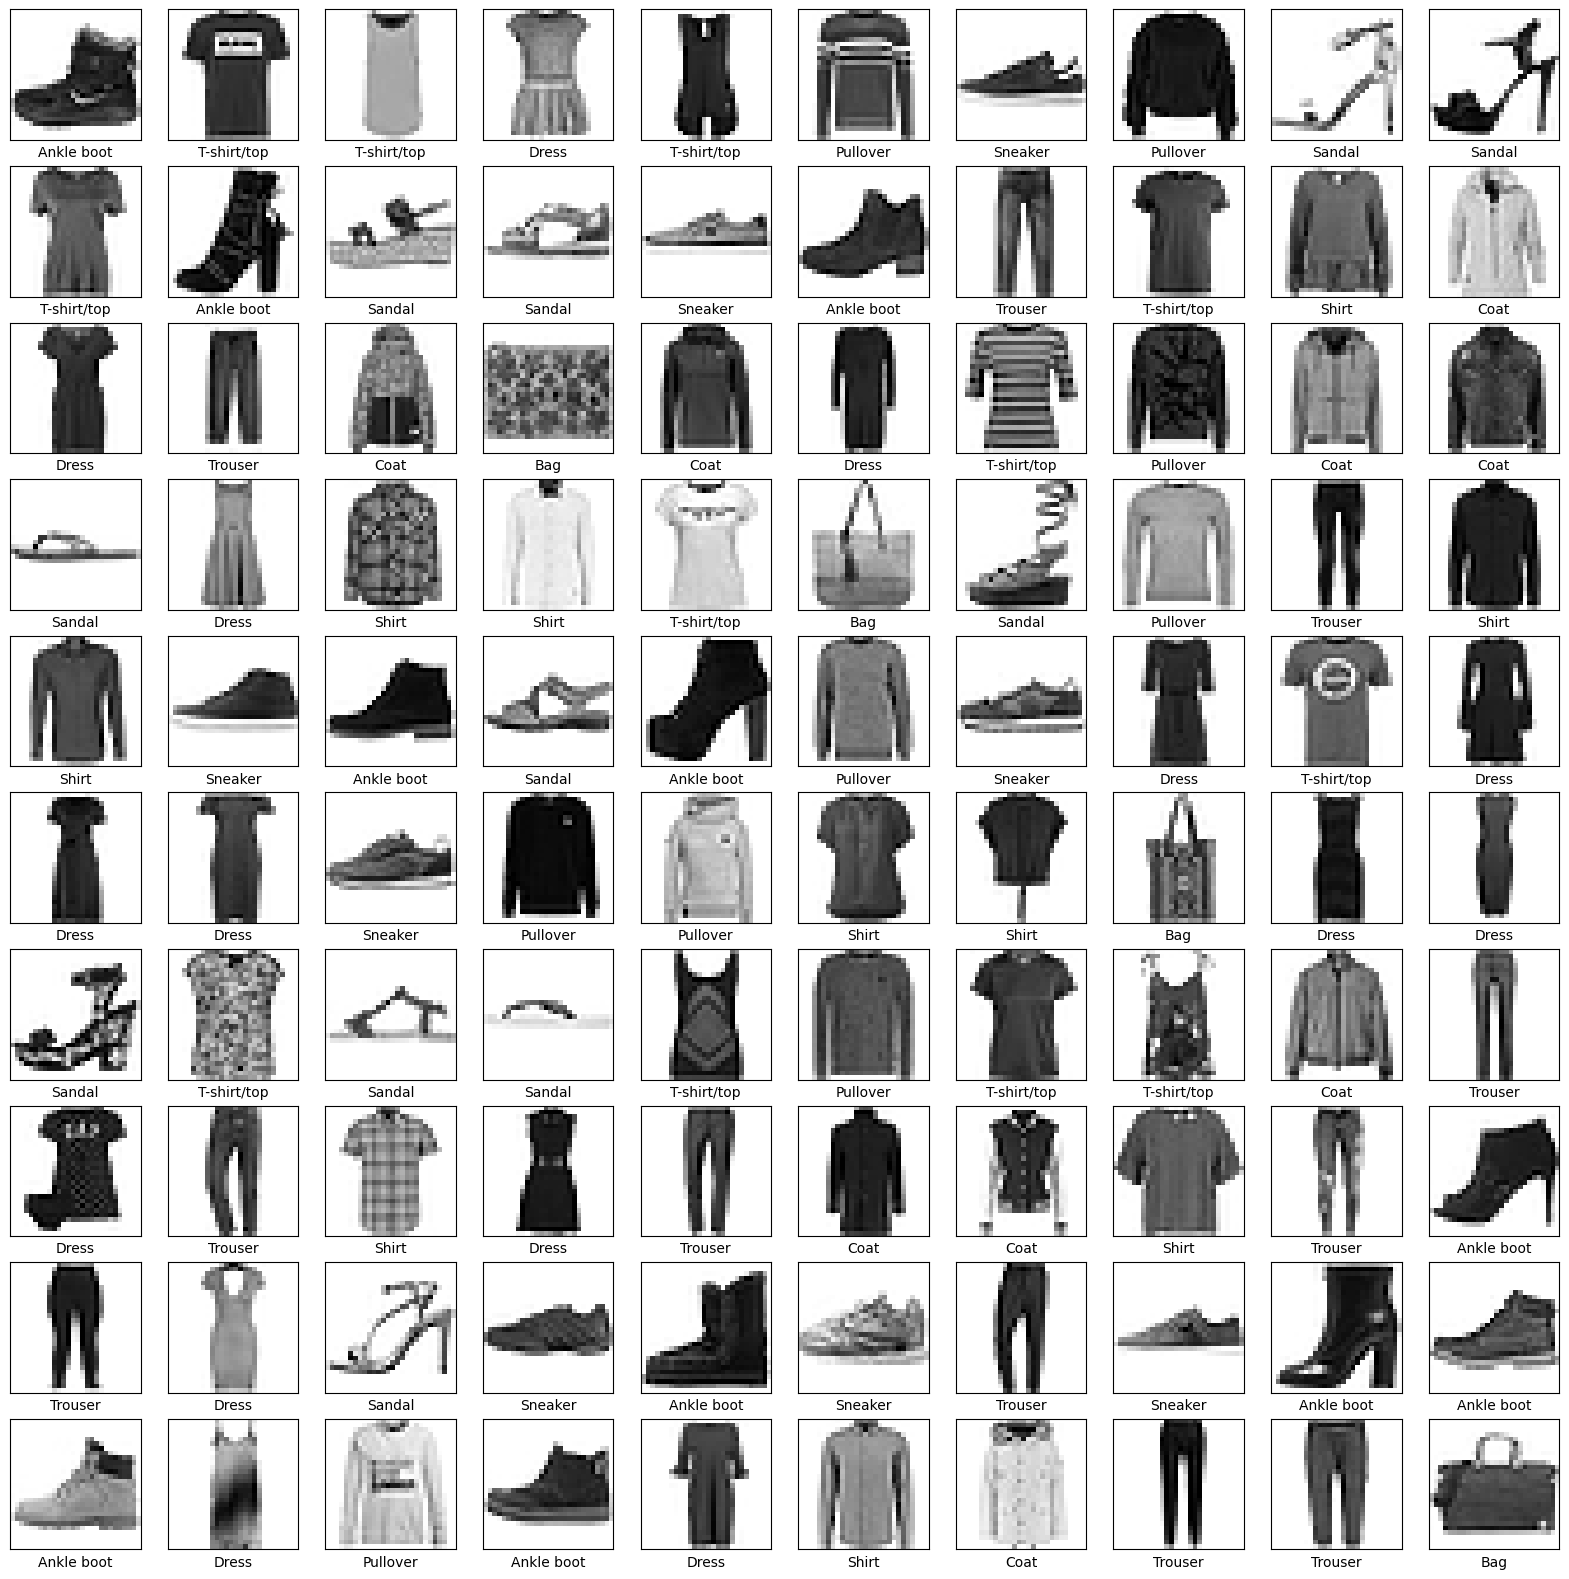

In [24]:
plt.figure(figsize=(20,20))
for i in range(100):
    plt.subplot(10,10,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_dataset[i][0].reshape(28, 28, 1), cmap=plt.cm.binary)
    plt.xlabel(label_names[train_dataset[i][1]])
plt.show()

### 모델 구축

In [25]:
# 기본 모델 = 완전연결계층 = Linear
class MyFirstModel(nn.Module):
    def __init__(self):
        super(MyFirstModel, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
            nn.Softmax()
        )

    def forward(self, x):
        output = self.model(x)
        return output

model = MyFirstModel()

In [26]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

optimizer = optim.Adadelta(model.parameters(), lr=1.0)
scheduler = StepLR(optimizer, step_size=1, gamma=0.7)

In [27]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=1024, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1024)

In [29]:
epochs = 10
dry_run = False # 1 배치만 훈련

for epoch in range(1, epochs+1):
    # 학습
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 3 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
            if dry_run:
                break

    # 테스트
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

    scheduler.step()

Train Epoch: 1 [0/60000 (0%)]	Loss: -0.603178
Train Epoch: 1 [3072/60000 (5%)]	Loss: -0.618137
Train Epoch: 1 [6144/60000 (10%)]	Loss: -0.635463
Train Epoch: 1 [9216/60000 (15%)]	Loss: -0.620716
Train Epoch: 1 [12288/60000 (20%)]	Loss: -0.625183
Train Epoch: 1 [15360/60000 (25%)]	Loss: -0.626673
Train Epoch: 1 [18432/60000 (31%)]	Loss: -0.604797
Train Epoch: 1 [21504/60000 (36%)]	Loss: -0.636502
Train Epoch: 1 [24576/60000 (41%)]	Loss: -0.611838
Train Epoch: 1 [27648/60000 (46%)]	Loss: -0.648756
Train Epoch: 1 [30720/60000 (51%)]	Loss: -0.617265
Train Epoch: 1 [33792/60000 (56%)]	Loss: -0.608567
Train Epoch: 1 [36864/60000 (61%)]	Loss: -0.639696
Train Epoch: 1 [39936/60000 (66%)]	Loss: -0.629056
Train Epoch: 1 [43008/60000 (71%)]	Loss: -0.631860
Train Epoch: 1 [46080/60000 (76%)]	Loss: -0.627829
Train Epoch: 1 [49152/60000 (81%)]	Loss: -0.592287
Train Epoch: 1 [52224/60000 (86%)]	Loss: -0.642242
Train Epoch: 1 [55296/60000 (92%)]	Loss: -0.655822
Train Epoch: 1 [58368/60000 (97%)]	Loss:

KeyboardInterrupt: 